In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from pathlib import Path
from math import ceil
import socket
import scipy.signal as signal

%matplotlib widget

## Notebook Setup

##### Append Code and Data Repository Paths

In [2]:
# Path to get to /home/rfsoc
home_dir = Path("./../..")
os.chdir(home_dir)

# Paths relative to /home/rfsoc
primecam_readout = Path('./primecam_readout')
ccatkidlib = Path('./ccatkidlib')
data_dir = Path('./../../mnt/md0')
 
# Append paths
sys.path.insert(0, os.path.abspath(ccatkidlib / 'rfsoc')) # Path contaning rfsoc_daq

##### Load Local Modules

In [30]:
%load_ext autoreload
%autoreload 2

from rfsoc_daq import R
import rfsoc_io
from rfsoc_timestream import Streamer

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---

## Data Acquisiton

In [31]:
# Initialize Control Object
R = R()

INFO | The directory '/mnt/md0/coldload_sweep/timestream/20241211/1733894295/B1D2' was successfully created!
INFO | The directory '/mnt/md0/coldload_sweep/vna/20241211/1733894295/B1D2' was successfully created!
INFO | The directory '/mnt/md0/coldload_sweep/targ/20241211/1733894295/B1D2' was successfully created!
INFO | The directory '/mnt/md0/coldload_sweep/rfsoc/20241211/1733894295/B1D2' was successfully created!
INFO | The directory '/mnt/md0/coldload_sweep/timestream/20241211/1733894295/B1D4' was successfully created!
INFO | The directory '/mnt/md0/coldload_sweep/vna/20241211/1733894295/B1D4' was successfully created!
INFO | The directory '/mnt/md0/coldload_sweep/targ/20241211/1733894295/B1D4' was successfully created!
INFO | The directory '/mnt/md0/coldload_sweep/rfsoc/20241211/1733894295/B1D4' was successfully created!
INFO | Successfully initialized logger: rfsoc_io
INFO | Successfully initialized timestream object using address 192.168.3.40 and port 4096!


In [32]:
R.find_detectors(new_sweep = False, peak_prom_std = 10, peak_prom_dB = 0, width_min = 5, width_max = 100, peak_dis = 100)

Status: Drone 1.1: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.2: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.3: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.4: ip=192.168.2.99, to_run=True, running=True
WARNING | Failed to fetch most recent file in '/mnt/md0/TEMP_DATA/vna/20241201/1733028632/B1D1' with identifier 'T*'
WARNING | Failed to fetch most recent file in '/mnt/md0/TEMP_DATA/vna/20241201/1733028632/B1D2' with identifier 'T*'
WARNING | Failed to fetch most recent file in '/mnt/md0/TEMP_DATA/vna/20241201/1733028632/B1D3' with identifier 'T*'
WARNING | Failed to fetch most recent file in '/mnt/md0/TEMP_DATA/vna/20241201/1733028632/B1D4' with identifier 'T*'
Status: Drone 1.1: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.2: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.3: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.4: ip=192.168.2.99, to_run=True, running=True
INFO | Writing new VNA comb!
INFO | 

Writing custom target comb: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 117/117 [01:57<00:00,  1.00s/it]


INFO | Found 109 detectors for drone 1.1!
INFO | Found 35 detectors for drone 1.2!
INFO | Found 1 detectors for drone 1.3!
INFO | Found 528 detectors for drone 1.4!


[109, 35, 1, 528]

In [5]:
R.take_target_sweep(com_to = ['1.2'], tone_freqs = [[500e6]], tone_powers = [[54]], tone_phis = [[0]])

Status: Drone 1.1: ip=192.168.2.99, to_run=False, running=True
Stopping drone 1.1 (for 43200 s)... Done.
Status: Drone 1.2: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.3: ip=192.168.2.99, to_run=False, running=True
Stopping drone 1.3 (for 43200 s)... Done.
Status: Drone 1.4: ip=192.168.2.99, to_run=False, running=True
Stopping drone 1.4 (for 43200 s)... Done.
INFO | Sucessfully wrote custom comb for board 1!
INFO | Taking target sweep!
INFO | Finished taking target sweep for board 1!


[PosixPath('/mnt/md0/TEMP_DATA/targ/20241202/1733167446/B1D2/TEST_targ_1733167643.npy')]

In [32]:
R.take_timestream(10, write_tones = False)

Status: Drone 1.1: ip=192.168.2.99, to_run=False, running=False
Status: Drone 1.2: ip=192.168.2.99, to_run=True, running=True
Status: Drone 1.3: ip=192.168.2.99, to_run=False, running=False
Status: Drone 1.4: ip=192.168.2.99, to_run=True, running=True
INFO | Taking 10 seconds of timestream data!
INFO | Storage space on board 1 is 12.149035008 GB!
INFO | Finished taking timestream data for board 1!
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
192.168.3.51
1

[[PosixPath('/mnt/md0/coldload_sweep/timestream/20241211/1733894295/B1D2/coldload_sweep_tstream_1733894298_001.npy')],
 [PosixPath('/mnt/md0/coldload_sweep/timestream/20241211/1733894295/B1D4/coldload_sweep_tstream_1733894298_001.npy'),
  PosixPath('/mnt/md0/coldload_sweep/timestream/20241211/1733894295/B1D4/coldload_sweep_tstream_1733894298_002.npy')]]

---

## Data Processing

In [116]:
# Data Directory Name
data_name = 'modcam_coldload_data'
date = '20241205'
sess_id = '1733427344'

In [117]:
# Load init IO config
io_cfg_name = f'{sess_id}_init_config_io.yaml'
cfg_dir = data_dir / data_name / 'rfsoc' / date / sess_id

io_cfg = rfsoc_io.load_config(cfg_dir / io_cfg_name)
print(io_cfg)

{'sess_id': '1733427344', 'drone_list': ['1.1', '1.2', '1.3', '1.4'], 'initialize': True, 'parallel': False, 'restart': False, 'udp_ip': '192.168.3.40', 'udp_port': 4096, 'boards': {'b1': {'board_ip': '192.168.2.99', 'sampling_freq': 488.28, 'drone_cfg': '/home/rfsoc/ccatkidlib/scripts/modcam_coldload/coldload_drone_config.yaml'}, 'b2': {'board_ip': '192.168.2.98', 'sampling_freq': 488.28, 'drone_cfg': '/home/rfsoc/ccatkidlib/rfsoc/drones_config_2.yaml'}}, 'file_paths': {'analysis_dir': '/home/rfsoc/ccatkidlib/analysis/', 'data_dir': '/mnt/md0/modcam_coldload_data', 'tmp_data_dir': '/home/rfsoc/primecam_readout/src/tmp', 'primecam_readout': '/home/rfsoc/primecam_readout/src/', 'master_drone_list': '/home/rfsoc/primecam_readout/master_drone_list.yaml', 'pcs_dir': '/home/rfsoc/ocs-site-configs/', 'RSA_key': '/home/rfsoc/.ssh/xilinx', 'drone_dir': '/home/xilinx/primecam_readout/drones'}, 'file_names': {'stream_fname': 'coldload_tstream', 'targ_fname': 'coldload_targ', 'vna_fname': 'coldlo

In [92]:
rfsoc_io.load_config(cfg_dir / "B1D1" / "1733212845_timestream_config_drone.yaml")['atten']

AssertionError: Could not find config file!

In [118]:
# Get parameters from io_cfg
drone_list = io_cfg['drone_list']
print(drone_list)

['1.1', '1.2', '1.3', '1.4']


### Sweeps

In [119]:
def plot_sweep(sweep_file, figax = None, label = "", n = 10):
    # Create axes object or use passed axes object
    if figax is None:
        fig, ax = plt.subplots(figsize = (8, 8))
    else:
        fig, ax = figax
    
    # Load VNA sweep data
    fs, s21z = np.load(sweep_file)
    fs = np.abs(fs) 
    s21m = np.abs(s21z)
    s21dB = 20*np.log10(s21m)
    
    ax.plot(fs[n:]/1e6, signal.medfilt(s21dB, kernel_size = n)[n:], label = label)
    #ax.set_xlabel("Frequency (MHz)")
    #ax.set_ylabel("|S21| (dB)")

    # Create legend if label was provided
    if label != "":
        ax.legend(loc = 1)
        
    return fs, s21z

##### VNA Sweeps

In [120]:
# Define VNA sweep data directory
vna_sweep_name = 'coldload_vna_'
vna_dir = data_dir / data_name / 'vna' / date / sess_id

for drone in drone_list:
    bid, drid = drone.split('.')
    dir_name = f'B{bid}D{drid}/'
    print(dir_name + ": " + str(os.listdir(vna_dir / dir_name)))

B1D1/: ['coldload_vna_1733427473.npy']
B1D2/: ['coldload_vna_1733427473.npy']
B1D3/: ['coldload_vna_1733427473.npy']
B1D4/: ['coldload_vna_1733427473.npy']


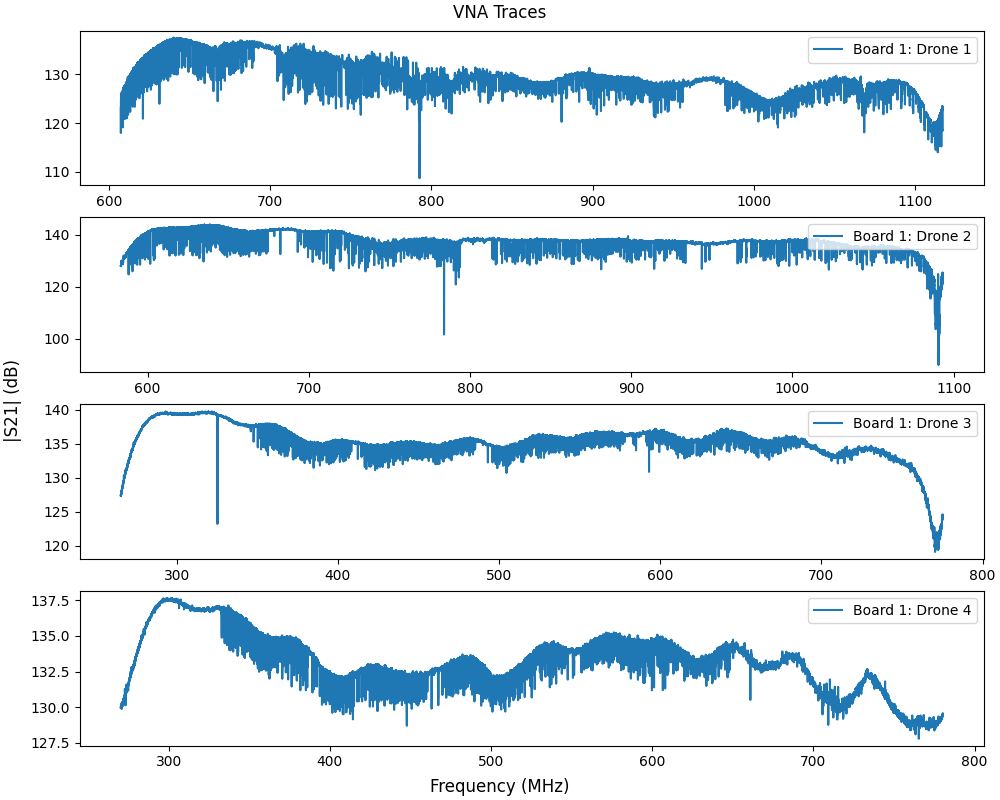

In [122]:
# Define timestamp of VNA sweeps
#timestamps = ['1733373179', '1733366187', '1733371784']
timestamps = ['1733427473']
# Plot VNA sweeps
num_cols = 1 # Define desired number of columns in figure
num_rows = ceil(len(drone_list) / num_cols) # Calculate number of rows necessary to plot all VNA sweeps

# Create figure
try:
    # Close the previous figure before creating a new one (otherwise they stay in memory)
    plt.close(fig_vna)
except:
    print("No figures currently open")

fig_vna, axes = plt.subplots(num_rows, num_cols, figsize = (10, 8), constrained_layout = True)

for timestamp in timestamps:
    # Iterate through each drone and plot corresponding VNA sweep
    for drone, ax in zip(drone_list, np.ndarray.flatten(axes)):
        bid, drid = drone.split('.')
        fname = vna_dir / (f'B{bid}D{drid}/' + vna_sweep_name + timestamp + ".npy")
        plot_sweep(fname, figax = (fig_vna, ax), label = f'Board {bid}: Drone {drid}', n = 1)
    fig_vna.supxlabel("Frequency (MHz)")
    fig_vna.supylabel("|S21| (dB)")
    fig_vna.suptitle("VNA Traces")

---

#### Target Sweep

In [137]:
# Define target sweep data directory
targ_sweep_name = 'coldload_targ_'
targ_dir = data_dir / data_name / 'targ' / date / sess_id

for drone in drone_list:
    bid, drid = drone.split('.')
    dir_name = f'B{bid}D{drid}/'
    print(dir_name + ": " + str(os.listdir(targ_dir / dir_name)))

B1D1/: ['coldload_targ_1733429139.npy', 'coldload_targ_1733429906.npy', 'coldload_targ_1733428631.npy', 'coldload_targ_1733427865.npy']
B1D2/: ['coldload_targ_1733429139.npy', 'coldload_targ_1733429906.npy', 'coldload_targ_1733428631.npy', 'coldload_targ_1733427865.npy']
B1D3/: ['coldload_targ_1733429139.npy', 'coldload_targ_1733429906.npy', 'coldload_targ_1733428631.npy', 'coldload_targ_1733427865.npy']
B1D4/: ['coldload_targ_1733429139.npy', 'coldload_targ_1733429906.npy', 'coldload_targ_1733428631.npy', 'coldload_targ_1733427865.npy']


(array([3.31954656e+08, 3.31958664e+08, 3.31962672e+08, ...,
        7.72639704e+08, 7.72643712e+08, 7.72647720e+08]),
 array([ -856467.4+1415178.j ,  -971244. +1654640.j ,
         -947611.8+1669007.6j, ..., -1466572.4-1242997.2j,
        -1479648.4-1229287.4j, -1496444.4-1202905.4j]))

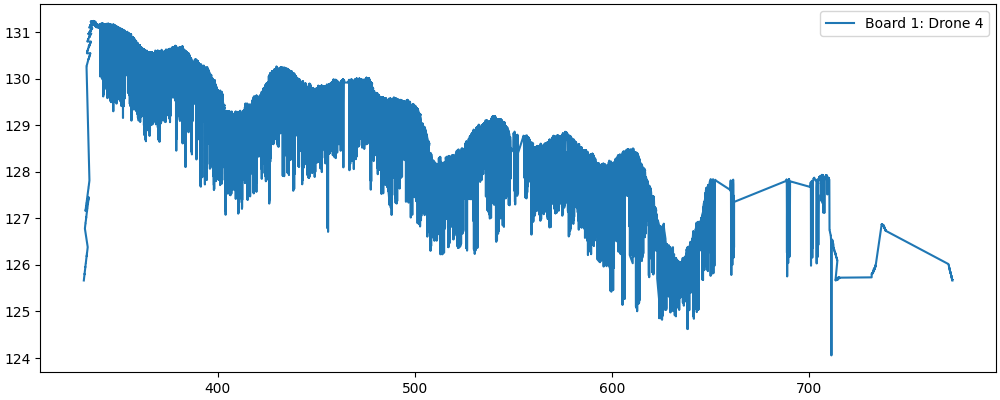

In [24]:
bid = 1
drid = 4
fig_vna, axes = plt.subplots(1, 1, figsize = (10, 4), constrained_layout = True)
fname = targ_dir / (f'B{bid}D{drid}/' + 'coldload_test_targ_1733212730.npy')
plot_sweep(fname, figax = (fig_vna, axes), label = f'Board {bid}: Drone {drid}', n = 7)

[330, 24, 431, 170, 257, 375, 262, 223, 32, 221]

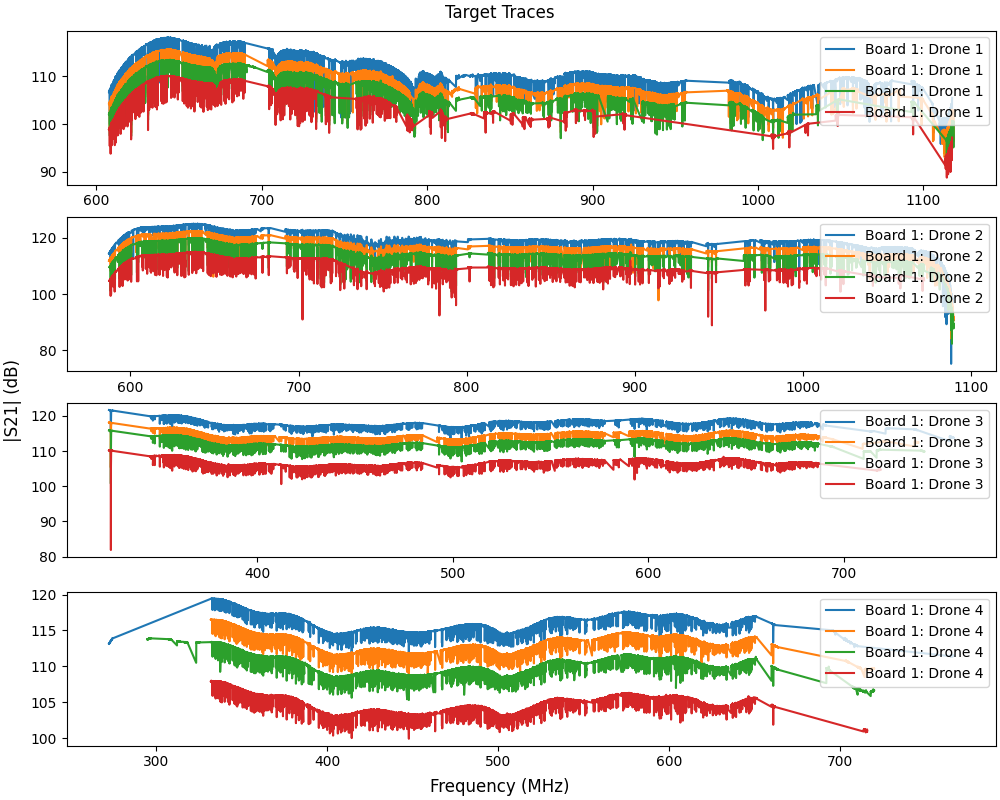

In [135]:
# Define timestamp of target sweeps
#timestamps = ['1733353810', '1733354391', '1733355221', '1733352989', '1733361616']
timestamps = ['1733427865', '1733428631', '1733429139', '1733429906']
# Plot target sweeps
num_cols = 1 # Define desired number of columns in figure
num_rows = ceil(len(drone_list) / num_cols) # Calculate number of rows necessary to plot all target sweeps

# Create figure
try:
    # Close the previous figure before creating a new one (otherwise they stay in memory)
    plt.close(fig_targ)
except:
    print("No figures currently open")

fig_targ, axes = plt.subplots(num_rows, num_cols, figsize = (10, 8), constrained_layout = True)

# Iterate through each drone and plot corresponding VNA sweep
for timestamp in timestamps:
    for drone, ax in zip(drone_list, np.ndarray.flatten(axes)):
        bid, drid = drone.split('.')
        fname = targ_dir / (f'B{bid}D{drid}/' + targ_sweep_name + timestamp + ".npy")
        plot_sweep(fname, figax = (fig_targ, ax), label = f'Board {bid}: Drone {drid}', n = 1)
    fig_targ.supxlabel("Frequency (MHz)")
    fig_targ.supylabel("|S21| (dB)")
    fig_targ.suptitle("Target Traces")

---

### Timestreams

In [10]:
def plot_tstream(tstream_file, chans = None, figax = None, label = ""):
    # Create axes object or use passed axes object
    if figax is None:
        fig, ax = plt.subplots(figsize = (8, 8))
    else:
        fig, ax = figax

    try:
        chan_num = len(chans)
    except:
        chans = [chans]
        chan_num = len(chans)
    
    # Load timestream data
    data = np.load(tstream_file)
    ts = data[0]

    for chan in chans:
        s21z = data[chan]
        s21m = np.abs(s21z)
        ax.plot(ts, 20*np.log10(s21m), label = label + f', Channel: {chan}')
        #ax.set_xlabel("Frequency (MHz)")
        #ax.set_ylabel("|S21| (dB)")

        # Create legend if label was provided
        if label != "":
            ax.legend(loc = 1)

[227, 398, 70, 159, 291, 276] 544


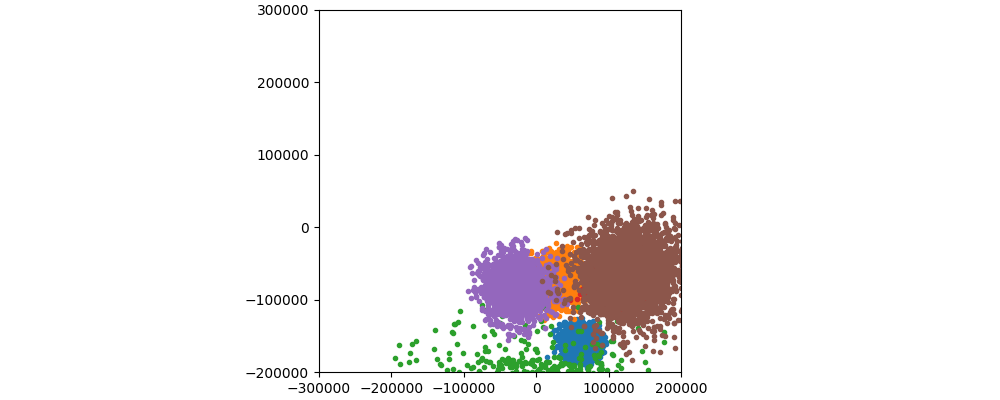

In [80]:
bid = 1
drid = 1
plt.clf()
plt.gca().set_aspect('equal')
fname = tstream_dir / (f'B{bid}D{drid}/' + 'coldload_test_tstream_1733220951_001.npy')
data = np.load(fname)
n_dets, counts = data.shape
N = [randint(0, n_dets-1) for i in range(6)]
print(N, n_dets)
for n in N: 
    plt.plot(data[n].real, data[n].imag, ".")

plt.xlim(-300000, 200000)
plt.ylim(-200000, 300000)
plt.show()

In [23]:
# Define timestream data directory
tstream_name = 'TEST_tstream_'
tstream_dir = data_dir / data_name / 'timestream' / date / sess_id

for drone in drone_list:
    bid, drid = drone.split('.')
    dir_name = f'B{bid}D{drid}/'
    print(dir_name + ": " + str(os.listdir(tstream_dir / dir_name)))

B1D1/: ['coldload_test_tstream_1733206917_001.npy', 'coldload_test_tstream_1733217268_003.npy', 'coldload_test_tstream_1733217268_001.npy', 'coldload_test_tstream_1733220951_002.npy', 'coldload_test_tstream_1733209843_003.npy', 'coldload_test_tstream_1733210587_001.npy', 'coldload_test_tstream_1733213588_002.npy', 'coldload_test_tstream_1733221673_003.npy', 'coldload_test_tstream_1733213588_003.npy', 'coldload_test_tstream_1733218736_003.npy', 'coldload_test_tstream_1733209126_003.npy', 'coldload_test_tstream_1733210587_003.npy', 'coldload_test_tstream_1733215051_001.npy', 'coldload_test_tstream_1733216523_002.npy', 'coldload_test_tstream_1733218009_003.npy', 'coldload_test_tstream_1733220220_003.npy', 'coldload_test_tstream_1733214326_003.npy', 'coldload_test_tstream_1733207670_003.npy', 'coldload_test_tstream_1733212845_001.npy', 'coldload_test_tstream_1733211322_001.npy', 'coldload_test_tstream_1733207670_001.npy', 'coldload_test_tstream_1733215051_002.npy', 'coldload_test_tstream_1

No figures currently open


/home/rfsoc/env_rfsoc/lib/python3.10/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/rfsoc/env_rfsoc/lib/python3.10/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 0.98, 'Timestreams')

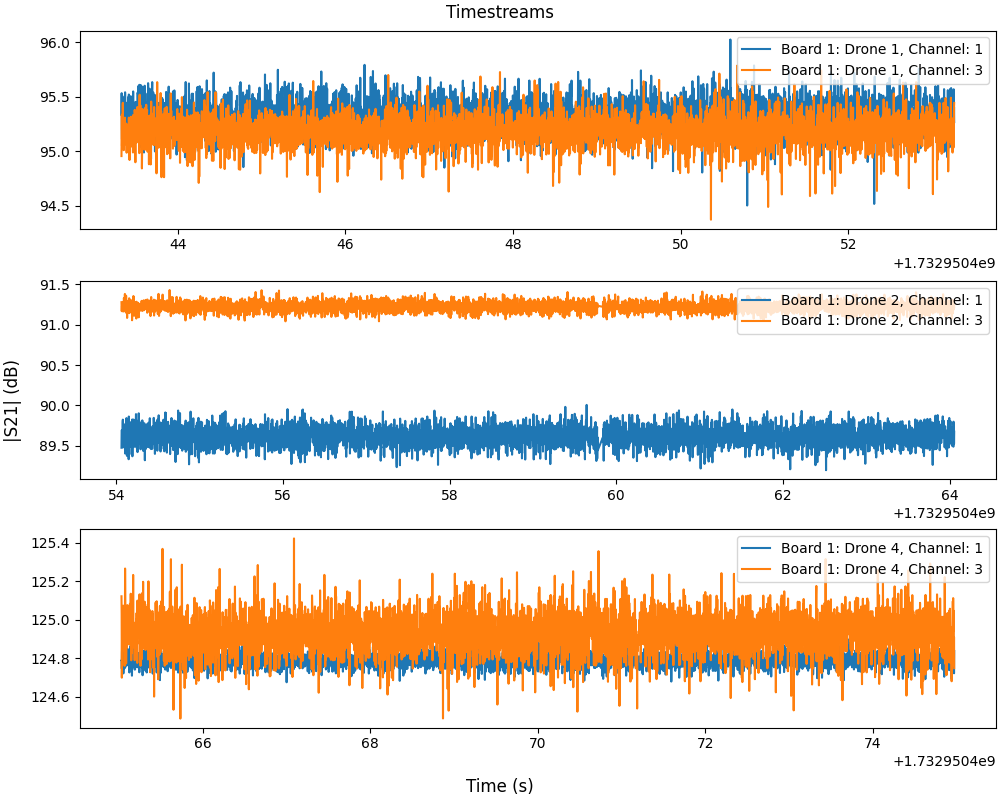

In [23]:
# Define timestamp of timestreams
timestamp = '1732950443_001'

# Plot timestreams
num_cols = 1 # Define desired number of columns in figure
num_rows = ceil(len(drone_list) / num_cols) # Calculate number of rows necessary to plot all timestreams

# Create figure
try:
    # Close the previous figure before creating a new one (otherwise they stay in memory)
    plt.close(fig_tstream)
except:
    print("No figures currently open")

fig_tstream, axes = plt.subplots(num_rows, num_cols, figsize = (10, 8), constrained_layout = True)

# Iterate through each drone and plot corresponding VNA sweep
channels = [[1,3],[1,3], [1,3]]
for drone, chans, ax in zip(drone_list, channels, np.ndarray.flatten(axes)):
    bid, drid = drone.split('.')
    fname = tstream_dir / (f'B{bid}D{drid}/' + tstream_name + timestamp + ".npy")
    plot_tstream(fname, chans = chans, figax = (fig_tstream, ax), label = f'Board {bid}: Drone {drid}')
fig_tstream.supxlabel("Time (s)")
fig_tstream.supylabel("|S21| (dB)")
fig_tstream.suptitle("Timestreams")

In [25]:
[1, 3, 4].tolist()

AttributeError: 'list' object has no attribute 'tolist'

ccatkidlib/  ocs-site-configs/         snap/
Desktop/     override_drone_list.yaml  Templates/
Documents/   Pictures/                 test_scpi_psu_client.py
Downloads/   primecam-ansible/         var_atten/
dump.rdb     primecam_readout/         Videos/
env_rfsoc/   Public/
Music/       redis/


In [5]:
streamer = Streamer('192.168.3.40', 4096)

In [7]:
streamer.take_timestream(100)

([array([  599524.,  1128712., -1048889.,  -616497.,  1318918.,  -963932.,
          1435241.,   797964.,  1430516.,   313046.,   176190., -1669765.,
          1033552.,  1498009., -1135660., -1429678.,  -294702., -2471010.,
         -2145153.,   613554., -2006722.,   327737., -2036005.,   275251.,
          1503988., -1884171.,  2910007.,  1716982.,  -162636., -2423582.,
         -2288644.,  -731924.,  1878575.,  1414929., -1836231.,  1780506.,
          2591074., -1357297., -1108237., -2401265., -1973535., -1168942.,
           450502.,  2420206.,  -616167., -2609140.,  -368022.,  2375116.,
         -4364356.,  -660582.,  2509751.,  -840752., -2290291., -1545558.,
          -709448.,  3216042.,   963721.,  3663989.,  1102047., -3187037.,
          2940263.,  2155836.,  -240431., -3587081.,  2503770.,  1816178.,
         -2399578.,  2455833.,  1649097., -3212502., -1294104., -4477620.,
          3363635.,   299048.,  2665814.,  1708458., -2453268., -1323650.,
         -2239298., -2076